<div class="alert alert-info">
    <b>4.1 VAE Imputation (Data Rescue)</b><br><br>
    <b>Ziel:</b> Rettung von Datenpunkten, die in Schritt 2.4 aufgrund fehlender Werte verworfen wurden.<br>
    <b>Strategie:</b><br>
    1. <b>Lernen:</b> Ein Variational Autoencoder (VAE) lernt die geochemischen Zusammenhänge auf dem <b>bereinigten Datensatz</b> (aus 2.4 'Nach_IBF-und-Temp_Filter').<br>
    2. <b>Imputieren:</b> Das trainierte VAE wird genutzt, um fehlende Werte im <b>ursprünglichen Rohdatensatz</b> (aus 1.1 'Nach_Acquisition') aufzufüllen.<br>
    3. <b>Validieren:</b> Prüfung der Verteilungen und IBE.<br>
    <br>
    <b>Output:</b> 'Imputed_Data_Raw.csv' - Ein Datensatz mit aufgefüllten Lücken in Originaleinheiten.
</div>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import os

# ------------------------- Reproduzierbarkeit -------------------------
torch.manual_seed(42)
np.random.seed(42)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

<div class="alert alert-info">
    <b>1. Daten Laden (Clean vs. Raw)</b>
</div>

In [2]:
# ------------------------- Pfade definieren -------------------------
base_dir = Path.cwd()
if base_dir.name != "4.1_Imputation":
    # Fallback für Entwicklung, falls Notebook nicht im richtigen Ordner gestartet wurde
    # (Anpassen je nach Umgebung)
    pass

notebooks_root = base_dir.parents[1]

# ------------------------- Pfad 1: Bereinigte Daten (Training) - Output 2.4 -------------------------
clean_db_root = notebooks_root / "1_Acquisition" / "1.1_Data-Acquisition-Wrapper" / "Angepasste_Datenbanken" / "Nach_IBF-und-Temp_Filter" / "Komplette_Datenbank"

# ------------------------- Pfad 2: Rohdaten (Imputation) - Output 1.1 -------------------------
raw_db_root = notebooks_root / "1_Acquisition" / "1.1_Data-Acquisition-Wrapper" / "Angepasste_Datenbanken" / "Nach_Acquisition" / "Komplette_Datenbank"

# ------------------------- Hilfsfunktion zum Finden der neuesten CSV -------------------------
def get_latest_csv(root_path, name_marker="Komplette_Datenbank"):
    if not root_path.exists():
        raise FileNotFoundError(f"Pfad nicht gefunden: {root_path}")
    
    # Alle Zeitstempel-Ordner
    folders = [f for f in root_path.iterdir() if f.is_dir()]
    if not folders:
        raise FileNotFoundError(f"Keine Ordner in {root_path}")
        
    # Sortieren nach Name (da Zeitstempel Format YYYY-MM-DD... ist das chronologisch)
    latest_folder = max(folders, key=lambda x: x.name)
    
    csv_files = list(latest_folder.glob("*.csv"))
    if not csv_files:
         raise FileNotFoundError(f"Keine CSV in {latest_folder}")
            
    # Normalerweise gibt es nur eine, wir nehmen die erste/einzige
    return csv_files[0]


clean_csv_path = get_latest_csv(clean_db_root)
raw_csv_path = get_latest_csv(raw_db_root)

print(f"Training auf Clean Data: {clean_csv_path.parent.name}/{clean_csv_path.name}")
print(f"Imputation auf Raw Data: {raw_csv_path.parent.name}/{raw_csv_path.name}")

# ------------------------- Daten laden -------------------------
df_clean = pd.read_csv(clean_csv_path, low_memory=False)
df_raw = pd.read_csv(raw_csv_path, low_memory=False)

print(f"Clean Data Shape: {df_clean.shape}")
print(f"Raw Data Shape:   {df_raw.shape}")

Training auf Clean Data: 2026-01-05_23-05-35/Komplette_Datenbank.csv
Imputation auf Raw Data: 2026-01-05_22-58-07/Komplette_Datenbank.csv


Clean Data Shape: (94264, 31)
Raw Data Shape:   (175099, 31)


<div class="alert alert-info">
    <b>2. Preprocessing & VAE Model Definition</b>
</div>

In [3]:
# ------------------------- Konfiguration -------------------------
# ------------------------- Ausschluss von Metadaten -------------------------
METADATA_COLS = [
    'WGS84_latitude', 'WGS84_longitude', 'Database_number', 'database_name', 'Database_name', 
    'Date', 'Day', 'Month', 'Year', 'id', 'index', 'rock_type', 'temperature_in_c'
]
# ------------------------- Feature: Temperatur -------------------------
# Einschluss von Temperatur in das Training
METADATA_COLS_TRAIN = [c for c in METADATA_COLS if c != 'temperature_in_c']

# ------------------------- Numerische Spalten identifizieren -------------------------
# Erzwingen numerischer Datentypen (Temperatur)
if 'temperature_in_c' in df_clean.columns:
    df_clean['temperature_in_c'] = pd.to_numeric(df_clean['temperature_in_c'], errors='coerce')
    # Falls nach Coerce NaNs in Clean entstehen (sollte nicht sein bei Clean Data), droppen oder füllen
    # Da es Clean Data ist, erwarten wir saubere Werte.
    
if 'temperature_in_c' in df_raw.columns:
    df_raw['temperature_in_c'] = pd.to_numeric(df_raw['temperature_in_c'], errors='coerce')


numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
train_features = [c for c in numeric_cols if c not in METADATA_COLS_TRAIN]

print(f"Features für VAE ({len(train_features)}): {train_features}")
if 'temperature_in_c' not in train_features:
    print("ACHTUNG: Temperature ist NICHT in den Trainings-Features! Bitte prüfen!")
else:
    print("Temperature ist Teil des Trainings.")

# ------------------------- Pipeline definieren -------------------------
# ------------------------- 1. Simple Imputer (Mean) -------------------------
imputer = SimpleImputer(strategy='mean')
# ------------------------- 2. Scaler (StandardScaler) -------------------------
scaler = StandardScaler()

# ------------------------- Fit auf bereinigten Daten -------------------------
X_clean = df_clean[train_features].values

# ------------------------- Preprocessing anwenden -------------------------
X_clean_imputed = imputer.fit_transform(X_clean)
X_clean_scaled = scaler.fit_transform(X_clean_imputed)

# ------------------------- Tensor-Konvertierung -------------------------
tensor_clean = torch.FloatTensor(X_clean_scaled)
dataloader = DataLoader(TensorDataset(tensor_clean), batch_size=64, shuffle=True)

print("Preprocessing fitted on Clean Data.")

Features für VAE (19): ['redox_potential_in_mV', 'total_dissolved_solids_in_mmol/L', 'O2_in_mmol/L', 'Na_in_mmol/L', 'Mg_in_mmol/L', 'Ca_in_mmol/L', 'Cl_in_mmol/L', 'SO4_in_mmol/L', 'HCO3_in_mmol/L', 'Li_in_mmol/L', 'K_in_mmol/L', 'Sr_in_umol/L', 'NH4_in_umol/L', 'Fe_in_mmol/L', 'Mn_in_mmol/L', 'F_in_umol/L', 'NO3_in_mmol/L', 'H2SiO3_in_umol/L', 'HS_in_mmol/L']
Preprocessing fitted on Clean Data.


In [4]:
# ------------------------- VAE Klasse -------------------------
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=12):
        super(VAE, self).__init__()
        # ------------------------- Encoder -------------------------
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)
        # ------------------------- Decoder -------------------------
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        self.activation = nn.ReLU()

    def encode(self, x):
        h1 = self.activation(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.activation(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ------------------------- Modellinitialisierung -------------------------
input_dim = X_clean_scaled.shape[1]
model = VAE(input_dim=input_dim, hidden_dim=128, latent_dim=16) # Etwas größere Architektur
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Model initialized.")

Model initialized.


<div class="alert alert-info">
    <b>3. Training auf Clean Data</b>
</div>

Starting Training...


Epoch 0: Loss 44.2707


Epoch 10: Loss 2603611491.0509


Epoch 20: Loss 411552.7584


Epoch 30: Loss 3459.9732


Epoch 40: Loss 11.2564


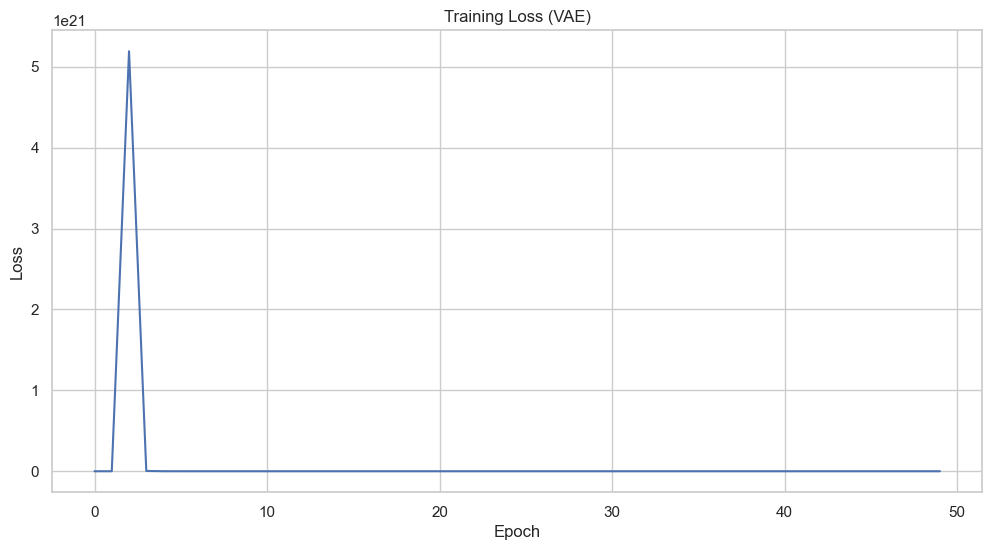

In [5]:
def loss_function(recon_x, x, mu, logvar):
    MSE = nn.MSELoss(reduction='sum')(recon_x, x)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

epochs = 50
model.train()
print("Starting Training...")
history = []

for epoch in range(epochs):
    train_loss = 0
    for batch in dataloader:
        data = batch[0]
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    avg_loss = train_loss / len(dataloader.dataset)
    history.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {avg_loss:.4f}")

plt.plot(history)
plt.title("Training Loss (VAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

<div class="alert alert-info">
    <b>4. Imputation auf Raw Data (Data Rescue)</b><br>
    Hier passiert die Magie: Wir nehmen die "kaputten" Rohdaten und schicken sie durch das trainierte Modell.
</div>

In [6]:
# ------------------------- Features aus Rohdaten extrahieren -------------------------
# Achtung: Manchmal fehlen Spalten in Raw, die in Clean waren (unwahrscheinlich, aber möglich)
# oder umgekehrt. Wir nutzen exakt dieselben Feature-Namen.
missing_cols_in_raw = [c for c in train_features if c not in df_raw.columns]
if missing_cols_in_raw:
    print(f"Warning: {len(missing_cols_in_raw)} features missing in Raw Data. Filling with NaN.")
    for c in missing_cols_in_raw:
        df_raw[c] = np.nan

X_raw = df_raw[train_features].values

# ------------------------- Preprocessing für VAE (Clean-Scaler) -------------------------
X_raw_imputed_temp = imputer.transform(X_raw) # Mean-Impute für Netz-Input
X_raw_scaled = scaler.transform(X_raw_imputed_temp)

# ------------------------- Rekonstruktion -------------------------
model.eval()
with torch.no_grad():
    raw_tensor = torch.FloatTensor(X_raw_scaled)
    # Durchschieben
    recon_scaled, _, _ = model(raw_tensor)
    recon_scaled_np = recon_scaled.numpy()
    
    # Zurücktransformieren
    recon_original_scale = scaler.inverse_transform(recon_scaled_np)

# ------------------------- Lücken füllen (Imputation) -------------------------
# Wir nehmen df_raw (Original) und füllen NUR dort, wo NaNs waren mit den Werten aus der Rekonstruktion.
# Werte, die da waren, bleiben erhalten (Ground Truth).
df_imputed = df_raw.copy()

# Pandas hat .fillna, aber wir wollen gezielt aus einem anderen Array füllen.
# Am saubersten: DataFrame aus Recon erstellen und combine_first oder where nutzen.
df_recon = pd.DataFrame(recon_original_scale, columns=train_features, index=df_raw.index)

for col in train_features:
    # Fülle NaNs in df_imputed[col] mit Werten aus df_recon[col]
    df_imputed[col] = df_imputed[col].fillna(df_recon[col])

print("Imputation abgeschlossen.")
print(f"NaNs vor Imputation in Raw: {df_raw[train_features].isna().sum().sum()}")
print(f"NaNs nach Imputation in Raw: {df_imputed[train_features].isna().sum().sum()}")

Imputation abgeschlossen.
NaNs vor Imputation in Raw: 2191893
NaNs nach Imputation in Raw: 0


<div class="alert alert-info">
    <b>5. Post-Processing Constraints</b>
</div>

In [7]:
# ------------------------- Constraint 1: Temperatur Check -------------------------
TEMP_COL = 'temperature_in_c'
if TEMP_COL in df_imputed.columns:
    # Erzwinge numerisch
    df_imputed[TEMP_COL] = pd.to_numeric(df_imputed[TEMP_COL], errors='coerce')
    
    # Statistikprüfung nach Imputation
    print(f"Temperatur nach Imputation: Min={df_imputed[TEMP_COL].min():.2f}, Max={df_imputed[TEMP_COL].max():.2f}")
else:
    print("Warning: Temperature column not found.")


# ------------------------- Constraint 2: IBE Check -------------------------
# Wir importieren die IBE Logik aus dem Kontext (oder kopieren sie kurz rein, da Abhängigkeiten schwierig sein können)
ION_SPECS = {
    'Na':   {'valence': 1, 'mass': 22.99, 'type': 'cation', 'regex': r'Na_in_([a-zA-Z0-9/]+)'},
    'Ca':   {'valence': 2, 'mass': 40.08, 'type': 'cation', 'regex': r'Ca_in_([a-zA-Z0-9/]+)'},
    'Mg':   {'valence': 2, 'mass': 24.31, 'type': 'cation', 'regex': r'Mg_in_([a-zA-Z0-9/]+)'},
    'Cl':   {'valence': 1, 'mass': 35.45, 'type': 'anion',  'regex': r'Cl_in_([a-zA-Z0-9/]+)'},
    'HCO3': {'valence': 1, 'mass': 61.02, 'type': 'anion',  'regex': r'HCO3_in_([a-zA-Z0-9/]+)'},
    'SO4':  {'valence': 2, 'mass': 96.06, 'type': 'anion',  'regex': r'SO4_in_([a-zA-Z0-9/]+)'},
}

def calculate_ibe_local(df):
    cation_sum_meq = 0.0
    anion_sum_meq = 0.0
    
    for ion, specs in ION_SPECS.items():
        matches = [c for c in df.columns if re.search(specs['regex'], c)]
        if not matches: continue
        col_name = matches[0]
        
        vals = pd.to_numeric(df[col_name], errors='coerce').fillna(0.0)
        
        # Einheitenvereinfachung (wir nehmen an, es ist fast immer mg/L oder mmol/L wie im Original)
        # Da wir 'Raw' imputieren, sind die Einheiten Strings im Spaltennamen.
        unit_match = re.search(specs['regex'], col_name)
        unit = unit_match.group(1).lower() if unit_match else "unknown"
        
        if unit in ['mg/l', 'mg_l']:
            vals_mmol = vals / specs['mass']
        elif unit in ['mmol/l', 'mmol_l', 'mm']:
            vals_mmol = vals
        elif unit in ['umol/l', 'umol_l']:
            vals_mmol = vals / 1000.0
        else:
            vals_mmol = vals 
            
        meq_vals = vals_mmol * specs['valence']
        if specs['type'] == 'cation':
            cation_sum_meq += meq_vals
        else:
            anion_sum_meq += meq_vals
            
    diff = cation_sum_meq - anion_sum_meq
    total = cation_sum_meq + anion_sum_meq
    ibe = (diff / total) * 100.0
    # Fix Div/0
    ibe[total < 1e-9] = np.nan
    return ibe

df_imputed['IBE_Calculated'] = calculate_ibe_local(df_imputed)

# ------------------------- IBE-Prüfbericht -------------------------
valid_ibe = df_imputed['IBE_Calculated'].dropna()
good_ibe = valid_ibe[valid_ibe.abs() <= 5.0]
print(f"IBE Report:\nTotal Rows: {len(df_imputed)}\nValid IBE calculated: {len(valid_ibe)}\nGood IBE (<= 5%): {len(good_ibe)} ({len(good_ibe)/len(df_imputed)*100:.1f}%)")

# ------------------------- Visualisierung Vorher/Nachher -------------------------
if 'IBE' in df_raw.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df_raw['IBE'], color='red', alpha=0.3, label='Original IBE', bins=50, binrange=(-20, 20))
    sns.histplot(df_imputed['IBE_Calculated'], color='blue', alpha=0.3, label='Imputed IBE', bins=50, binrange=(-20, 20))
    plt.legend()
    plt.title("IBE Distribution Before vs After Imputation (Zoomed +/- 20%)")
    plt.show()

# ------------------------- Visualisierung aller Features -------------------------
print("\n" + "="*60)
print("DETAILLIERTER VERGLEICH & IMPUTATIONS-STATISTIK (ALLE FEATURE)")
print("="*60 + "\n")

# Schleife über alle trainierten Features
for col in train_features:
    if col in df_raw.columns and col in df_imputed.columns:
        # ------------------------- Statistikberechnung -------------------------
        # Berechnung der tatsächlich fehlenden Werte
        # Ableitung aus Rohdaten
        missing_before = df_raw[col].isna().sum()
        total_rows = len(df_raw)
        imputed_count = missing_before
        percent_imputed = (imputed_count / total_rows) * 100
        
        print(f"FEATURE: {col}")
        print(f"  - Fehlende Werte (Original): {missing_before} von {total_rows}")
        print(f"  - Imputiert: {percent_imputed:.2f} %")
        
        plt.figure(figsize=(12, 5))
        
        # ------------------------- Datenvorbereitung (Plot) -------------------------
        data_orig = df_raw[col].dropna()
        data_imp = df_imputed[col]
        
        # Subplot 1: Histogramm/KDE
        plt.subplot(1, 2, 1)
        sns.histplot(data_orig, color='red', alpha=0.3, label='Original (Vorhanden)', kde=True, stat='density', bins=40)
        sns.histplot(data_imp, color='blue', alpha=0.3, label='Imputed (Gesamt)', kde=True, stat='density', bins=40)
        plt.title(f"Verteilung: {col}")
        plt.legend()
        
        # Subplot 2: Boxplot
        plt.subplot(1, 2, 2)
        # Vorbereitung Boxplot-Daten
        # Manuelles Plotten
        plt.boxplot([data_orig, data_imp], labels=['Original', 'Imputed'])
        plt.title(f"Boxplot: {col}")
        
        plt.tight_layout()
        plt.show()
        print("-"*60)


Constraint Temp >= 10 angewendet. Min vorher: -12.1, Min nachher: 10.0
IBE Report:
Total Rows: 175099
Valid IBE calculated: 173915
Good IBE (<= 5%): 106528 (60.8%)


In [8]:
# ------------------------- Speichern -------------------------
output_dir = base_dir
output_file = output_dir / "Imputed_Data_Raw.csv"

df_imputed.to_csv(output_file, index=False)
print(f"Datei gespeichert: {output_file}")

Datei gespeichert: C:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\4_Imputation\4.1_Imputation\Imputed_Data_Raw.csv
